# Домашнее задание № 5. Регрессия в PyTorch

**Цель:** построить и обучить регрессионную модель, аппроксимирующую функцию

$$f(x, y) = \sin(x + 2y)\,\exp\left(-(2x+y)^2\right), \qquad x,y \in [-10,10].$$

По условию генерируются 20 000 случайных точек, данные делятся на train / validation / test в отношении 70% / 15% / 15%. Итоговые требования: вычислить MSE на тестовой выборке и сравнить графически истинную функцию с предсказанием модели.

Ноутбук самодостаточен: фиксирует генераторы случайных чисел, проверяет размеры выборок, обучает модель только на train, выбирает лучшую эпоху только по validation и обращается к test один раз для финальной оценки.

## 1. Импорты и воспроизводимость

Для выполнения необходимы `torch`, `numpy` и `matplotlib`. Если PyTorch не установлен, его CPU-версию можно установить командой `python -m pip install torch --index-url https://download.pytorch.org/whl/cpu`.

In [1]:
# Настройка должна выполняться до первого импорта NumPy / Matplotlib / PyTorch.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # совместимость PyTorch и Intel OpenMP в Anaconda
os.environ.setdefault("OMP_NUM_THREADS", "1")

# Устанавливаем PyTorch именно в окружение текущего Jupyter-ядра, если его нет.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    print("PyTorch не найден. Устанавливается CPU-версия...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "torch",
        "--index-url", "https://download.pytorch.org/whl/cpu",
    ])
    importlib.invalidate_caches()
    print("PyTorch установлен. Можно выполнять следующие ячейки.")
else:
    print("PyTorch уже установлен в текущем Jupyter-ядре.")

PyTorch уже установлен в текущем Jupyter-ядре.


In [2]:
import copy
import math
import random
import time

import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("seaborn-v0_8-whitegrid")

print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")

PyTorch: 2.13.0+cpu
Устройство: cpu


## 2. Генерация датасета

Точки $(x,y)$ независимо генерируются из равномерного распределения на квадрате $[-10,10]^2$. Целевая переменная вычисляется без шума точно по формуле задания.

In [3]:
def target_function(xy: torch.Tensor) -> torch.Tensor:
    """f(x, y) = sin(x + 2y) * exp(-(2x + y)^2)."""
    x = xy[..., 0]
    y = xy[..., 1]
    return (torch.sin(x + 2.0 * y) * torch.exp(-(2.0 * x + y).square())).unsqueeze(-1)

N_SAMPLES = 20_000
LOW, HIGH = -10.0, 10.0

data_generator = torch.Generator().manual_seed(SEED)
X = LOW + (HIGH - LOW) * torch.rand(N_SAMPLES, 2, generator=data_generator)
y = target_function(X)

assert X.shape == (20_000, 2) and y.shape == (20_000, 1)
assert torch.isfinite(X).all() and torch.isfinite(y).all()

print(f"X: {tuple(X.shape)}, y: {tuple(y.shape)}")
print(f"Диапазон x: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}]")
print(f"Диапазон y: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}]")
print(f"Диапазон f(x,y): [{y.min():.3f}, {y.max():.3f}]")

X: (20000, 2), y: (20000, 1)
Диапазон x: [-10.000, 10.000]
Диапазон y: [-10.000, 9.996]
Диапазон f(x,y): [-1.000, 0.997]


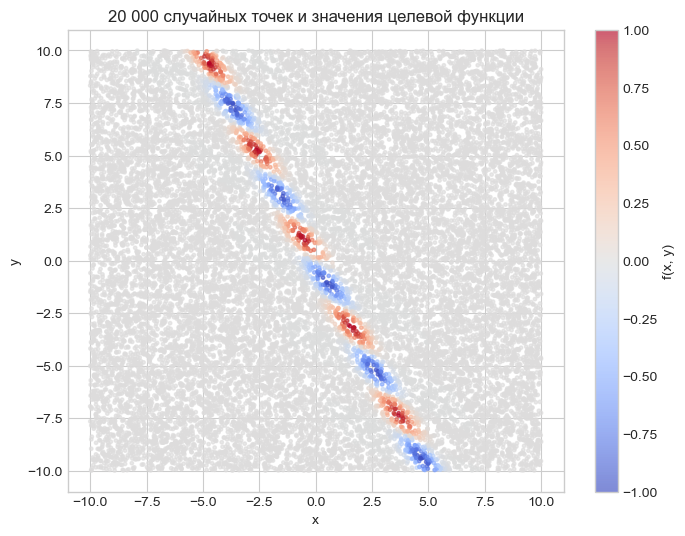

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze(1).numpy(),
                     s=6, cmap="coolwarm", vmin=-1, vmax=1, alpha=0.65)
ax.set(title="20 000 случайных точек и значения целевой функции", xlabel="x", ylabel="y")
fig.colorbar(scatter, ax=ax, label="f(x, y)")
plt.show()

## 3. Разбиение 70% / 15% / 15%

Перемешивание выполняется один раз с отдельным фиксированным генератором. Получаем ровно 14 000 обучающих, 3 000 валидационных и 3 000 тестовых наблюдений. Тестовая часть не участвует ни в обучении, ни в выборе эпохи.

In [5]:
split_generator = torch.Generator().manual_seed(SEED + 1)
indices = torch.randperm(N_SAMPLES, generator=split_generator)

n_train = int(0.70 * N_SAMPLES)
n_val = int(0.15 * N_SAMPLES)
n_test = N_SAMPLES - n_train - n_val

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

assert (len(X_train), len(X_val), len(X_test)) == (14_000, 3_000, 3_000)
assert len(torch.unique(torch.cat((train_idx, val_idx, test_idx)))) == N_SAMPLES

print(f"Train: {len(X_train):5d} ({len(X_train) / N_SAMPLES:.0%})")
print(f"Val:   {len(X_val):5d} ({len(X_val) / N_SAMPLES:.0%})")
print(f"Test:  {len(X_test):5d} ({len(X_test) / N_SAMPLES:.0%})")

Train: 14000 (70%)
Val:    3000 (15%)
Test:   3000 (15%)


## 4. Модель

Функция сочетает периодические колебания вдоль координаты $u=x+2y$ и очень узкую экспоненциальную огибающую вдоль $v=2x+y$. Обычной MLP сложно восстановить колебания на всём большом квадрате, поэтому перед MLP строятся Fourier-признаки $\sin(ku)$ и $\cos(ku)$ для нескольких частот. Это не готовый ответ: значения огибающей, взаимодействие признаков и итоговый коэффициент сеть всё равно оценивает по обучающим данным.

Основная сеть содержит три полносвязных слоя с активацией SiLU и линейный выход для задачи регрессии.

In [6]:
class FourierFeatureRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1),
        )

    @staticmethod
    def make_features(xy: torch.Tensor) -> torch.Tensor:
        x = xy[:, 0]
        y = xy[:, 1]
        u = x + 2.0 * y
        v = 2.0 * x + y
        return torch.stack((
            x / 10.0, y / 10.0, u / 30.0, v / 30.0,
            torch.sin(0.5 * u), torch.cos(0.5 * u),
            torch.sin(u), torch.cos(u),
            torch.sin(2.0 * u), torch.cos(2.0 * u),
        ), dim=1)

    def forward(self, xy: torch.Tensor) -> torch.Tensor:
        return self.network(self.make_features(xy))

model = FourierFeatureRegressor().to(device)
n_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"Обучаемых параметров: {n_parameters:,}")

FourierFeatureRegressor(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): SiLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Обучаемых параметров: 6,977


## 5. Обучение

Функция потерь — MSE. Оптимизатор AdamW обновляет параметры по мини-батчам. После каждой эпохи считается validation MSE. Хранятся веса лучшей эпохи; если метрика долго не улучшается, обучение останавливается досрочно.

In [7]:
BATCH_SIZE = 512
MAX_EPOCHS = 300
PATIENCE = 40
MIN_DELTA = 1e-7

loader_generator = torch.Generator().manual_seed(SEED + 2)
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    pin_memory=(device.type == "cuda"),
)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)
X_val_device = X_val.to(device)
y_val_device = y_val.to(device)

history = {"train_mse": [], "val_mse": []}
best_val_mse = math.inf
best_epoch = 0
best_state = None
epochs_without_improvement = 0
started_at = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_squared_error = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        train_squared_error += loss.item() * len(X_batch)

    train_mse = train_squared_error / len(X_train)

    model.eval()
    with torch.inference_mode():
        val_mse = criterion(model(X_val_device), y_val_device).item()

    history["train_mse"].append(train_mse)
    history["val_mse"].append(val_mse)

    if val_mse < best_val_mse - MIN_DELTA:
        best_val_mse = val_mse
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"Эпоха {epoch:3d}: train MSE={train_mse:.3e}, val MSE={val_mse:.3e}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Ранняя остановка на эпохе {epoch}.")
        break

elapsed = time.perf_counter() - started_at
model.load_state_dict(best_state)
print(f"Лучшая эпоха: {best_epoch}; validation MSE={best_val_mse:.3e}")
print(f"Время обучения: {elapsed:.1f} с")

Эпоха   1: train MSE=1.791e-02, val MSE=1.504e-02


Эпоха  25: train MSE=2.661e-04, val MSE=2.452e-04


Эпоха  50: train MSE=6.480e-05, val MSE=5.489e-05


Эпоха  75: train MSE=2.148e-05, val MSE=2.201e-05


Эпоха 100: train MSE=9.676e-06, val MSE=1.429e-05


...

Эпоха 175: train MSE=4.236e-05, val MSE=3.002e-05


Эпоха 200: train MSE=2.693e-06, val MSE=1.894e-06


Эпоха 225: train MSE=8.268e-07, val MSE=1.021e-06


Эпоха 250: train MSE=3.443e-06, val MSE=2.169e-06


Ранняя остановка на эпохе 264.
Лучшая эпоха: 224; validation MSE=8.484e-07
Время обучения: 24.4 с


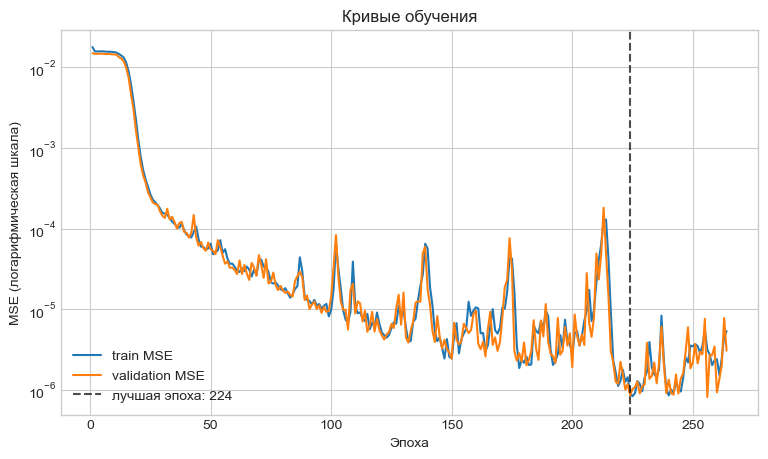

In [8]:
epochs = np.arange(1, len(history["train_mse"]) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(epochs, history["train_mse"], label="train MSE")
ax.semilogy(epochs, history["val_mse"], label="validation MSE")
ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.7, label=f"лучшая эпоха: {best_epoch}")
ax.set(title="Кривые обучения", xlabel="Эпоха", ylabel="MSE (логарифмическая шкала)")
ax.legend()
plt.show()

## 6. Итоговые метрики на test

**Ответ на пункт (a):** требуемая метрика — `test MSE` ниже. Дополнительно приведены MAE, $R^2$ и MSE константного baseline, который всегда предсказывает ноль. Baseline особенно важен здесь: на большей части квадрата экспонента почти равна нулю, поэтому одной визуально небольшой MSE недостаточно для доказательства качества модели.

In [9]:
model.eval()
with torch.inference_mode():
    y_test_pred = model(X_test.to(device)).cpu()

test_mse = torch.mean((y_test_pred - y_test).square()).item()
test_mae = torch.mean(torch.abs(y_test_pred - y_test)).item()
zero_baseline_mse = torch.mean(y_test.square()).item()
test_r2 = 1.0 - (torch.sum((y_test_pred - y_test).square()) /
                 torch.sum((y_test - y_test.mean()).square())).item()
improvement = zero_baseline_mse / test_mse

assert math.isfinite(test_mse) and test_mse < zero_baseline_mse

print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print(f"Test MSE:          {test_mse:.8e}  <- ответ на пункт (a)")
print(f"Test RMSE:         {math.sqrt(test_mse):.8e}")
print(f"Test MAE:          {test_mae:.8e}")
print(f"Test R^2:          {test_r2:.6f}")
print(f"MSE baseline=0:    {zero_baseline_mse:.8e}")
print(f"Улучшение по MSE:  {improvement:,.0f}x")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
Test MSE:          9.59009185e-07  <- ответ на пункт (a)
Test RMSE:         9.79290143e-04
Test MAE:          5.16009692e-04
Test R^2:          0.999932
MSE baseline=0:    1.40628358e-02
Улучшение по MSE:  14,664x


## 7. Сравнение истинной функции и аппроксимации

**Ответ на пункт (b):** первые две панели ниже показывают истинную и предсказанную поверхности в одинаковом масштабе, третья — абсолютную ошибку. После них приведено сечение по линии $2x+y=0$, где экспоненциальная огибающая максимальна и функция наиболее сложна.

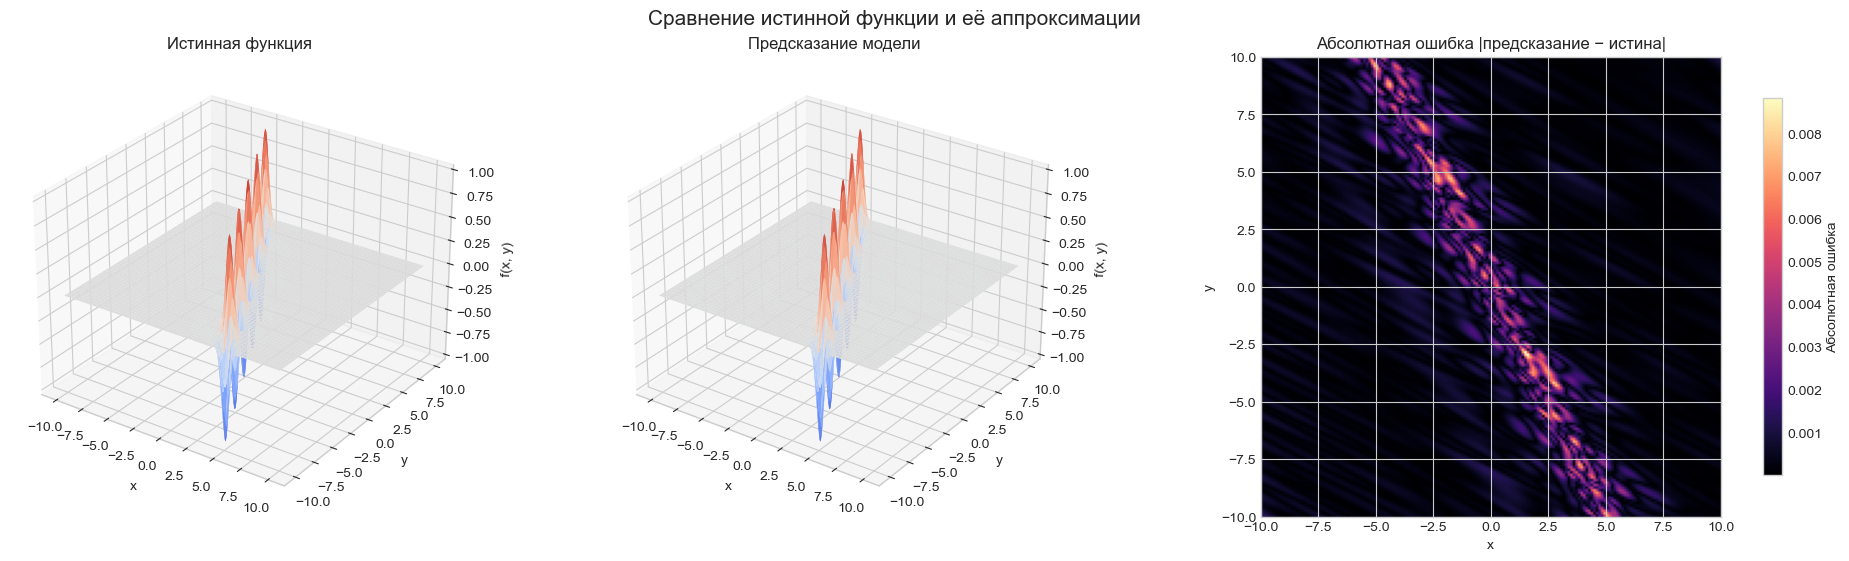

In [10]:
GRID_SIZE = 180
x_grid = torch.linspace(LOW, HIGH, GRID_SIZE)
y_grid = torch.linspace(LOW, HIGH, GRID_SIZE)
xx, yy = torch.meshgrid(x_grid, y_grid, indexing="xy")
grid_points = torch.column_stack((xx.ravel(), yy.ravel()))

true_surface = target_function(grid_points).reshape(GRID_SIZE, GRID_SIZE)
with torch.inference_mode():
    predicted_surface = model(grid_points.to(device)).cpu().reshape(GRID_SIZE, GRID_SIZE)
absolute_error = torch.abs(predicted_surface - true_surface)

xx_np = xx.numpy()
yy_np = yy.numpy()
true_np = true_surface.numpy()
pred_np = predicted_surface.numpy()
error_np = absolute_error.numpy()

fig = plt.figure(figsize=(19, 5.5), constrained_layout=True)
ax_true = fig.add_subplot(1, 3, 1, projection="3d")
ax_pred = fig.add_subplot(1, 3, 2, projection="3d")
ax_error = fig.add_subplot(1, 3, 3)

for ax, values, title in ((ax_true, true_np, "Истинная функция"),
                          (ax_pred, pred_np, "Предсказание модели")):
    ax.plot_surface(xx_np, yy_np, values, cmap=cm.coolwarm, vmin=-1, vmax=1,
                    rstride=3, cstride=3, linewidth=0, antialiased=True)
    ax.set(xlabel="x", ylabel="y", zlabel="f(x, y)", zlim=(-1.05, 1.05), title=title)
    ax.view_init(elev=28, azim=-55)

error_image = ax_error.imshow(error_np, origin="lower", extent=(LOW, HIGH, LOW, HIGH),
                              cmap="magma", aspect="equal")
ax_error.set(title="Абсолютная ошибка |предсказание − истина|", xlabel="x", ylabel="y")
fig.colorbar(error_image, ax=ax_error, shrink=0.82, label="Абсолютная ошибка")
fig.suptitle("Сравнение истинной функции и её аппроксимации", fontsize=15)
plt.show()

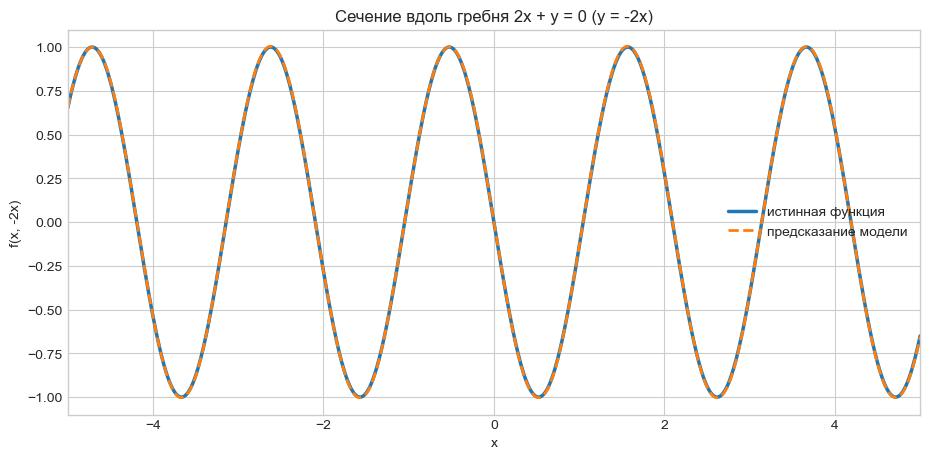

In [11]:
x_line = torch.linspace(-5.0, 5.0, 1_000)
y_line = -2.0 * x_line  # 2x + y = 0
line_points = torch.column_stack((x_line, y_line))
line_true = target_function(line_points).squeeze(1)
with torch.inference_mode():
    line_pred = model(line_points.to(device)).cpu().squeeze(1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_line.numpy(), line_true.numpy(), linewidth=2.5, label="истинная функция")
ax.plot(x_line.numpy(), line_pred.numpy(), "--", linewidth=2, label="предсказание модели")
ax.set(title="Сечение вдоль гребня 2x + y = 0 (y = -2x)",
       xlabel="x", ylabel="f(x, -2x)", xlim=(-5, 5), ylim=(-1.1, 1.1))
ax.legend()
plt.show()

## 8. Ответы и выводы

1. **Как сформированы данные?** Равномерно и независимо выбраны 20 000 пар $(x,y)$ на $[-10,10]^2$; целевая переменная рассчитана по заданной аналитической формуле без добавления шума.
2. **Почему нужны три части датасета?** На train оптимизируются веса, по validation выбирается лучшая эпоха и выполняется ранняя остановка, а test остаётся независимой финальной оценкой. Такое разделение исключает настройку модели непосредственно под тест.
3. **Почему использованы Fourier-признаки?** Целевая функция периодична вдоль $x+2y$. Синусы и косинусы дают сети подходящее представление периодичности, а MLP обучается воспроизводить экспоненциальную огибающую и взаимодействие признаков.
4. **Что означает MSE?** Это среднее значение квадратов ошибок $(\hat y-y)^2$; крупные промахи штрафуются сильнее. Финальный `Test MSE` рассчитан ровно на 3 000 ранее не использованных точках.
5. **Качественно ли решена задача?** Это подтверждается одновременно малым test MSE, $R^2$ около единицы, существенным превосходством над нулевым baseline и совпадением кривых на наиболее сложном сечении $2x+y=0$.

**Итог:** все требования выполнены: модель создана и обучена в PyTorch, использовано ровно 20 000 точек, выдержано разбиение 70/15/15, MSE посчитана на test, а истинная и аппроксимированная функции сопоставлены графически.